In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Inspecting The Data

In [2]:
df = pd.read_csv('earthquake_1995-2023.csv')

print(df.head()) # Initial inspection of the data
print(df.columns)

                                      title  magnitude         date_time  cdi  \
0          M 6.5 - 42 km W of Sola, Vanuatu        6.5  16-08-2023 12:47    7   
1  M 6.5 - 43 km S of Intipucá, El Salvador        6.5  19-07-2023 00:22    8   
2  M 6.6 - 25 km ESE of Loncopué, Argentina        6.6  17-07-2023 03:05    7   
3     M 7.2 - 98 km S of Sand Point, Alaska        7.2  16-07-2023 06:48    6   
4                  M 7.3 - Alaska Peninsula        7.3  16-07-2023 06:48    0   

   mmi   alert  tsunami  sig net  nst      dmin    gap magType    depth  \
0    4   green        0  657  us  114  7.177000   25.0     mww  192.955   
1    6  yellow        0  775  us   92  0.679000   40.0     mww   69.727   
2    5   green        0  899  us   70  1.634000   28.0     mww  171.371   
3    6   green        1  860  us  173  0.907000   36.0     mww   32.571   
4    5     NaN        1  820  at   79  0.879451  172.8      Mi   21.000   

   latitude  longitude               location      continent  

Data dictionary (directly from source of data):

* title - Title name given to the earthquake
* magnitude - The magnitude of the earthquake
* date_time - Date and time
* cdi - The maximum reported intensity for the event range
* mmi - The maximum estimated instrumental intensity for the event
* alert - The alert level - “green”, “yellow”, “orange”, and “red”
* tsunami - "1" for events in oceanic regions and "0" otherwise
* sig - A number describing how significant the event is. Larger numbers indicate a more significant event. This value is determined on a number of factors, including: magnitude, maximum MMI, felt reports, and estimated impact
* net - The ID of a data contributor. Identifies the network considered to be the preferred source of information for this event
* nst - The total number of seismic stations used to determine earthquake location
* dmin - Horizontal distance from the epicenter to the nearest station
* gap - The largest azimuthal gap between azimuthally adjacent stations (in degrees). In general, the smaller this number, the more reliable is the calculated horizontal position of the earthquake. Earthquake locations in which the azimuthal gap exceeds 180 degrees typically have large location and depth uncertainties
* magtype - The method or algorithm used to calculate the preferred magnitude for the event
* depth - The depth where the earthquake begins to rupture
* latitude - coordinate system by means of which the position or location of any place on Earth's surface can be determined and described
* longtitude - ^^^
* location - Location within the country
* continent - Continent of the earthquake hit country
* country - Affected country

## Data Information

In [3]:
print(df.info)
print(df.dtypes) # Want to know more of what the data looks like

<bound method DataFrame.info of                                          title  magnitude         date_time  \
0             M 6.5 - 42 km W of Sola, Vanuatu        6.5  16-08-2023 12:47   
1     M 6.5 - 43 km S of Intipucá, El Salvador        6.5  19-07-2023 00:22   
2     M 6.6 - 25 km ESE of Loncopué, Argentina        6.6  17-07-2023 03:05   
3        M 7.2 - 98 km S of Sand Point, Alaska        7.2  16-07-2023 06:48   
4                     M 7.3 - Alaska Peninsula        7.3  16-07-2023 06:48   
..                                         ...        ...               ...   
995          M 7.1 - 85 km S of Tungor, Russia        7.1  27-05-1995 13:03   
996     M 7.7 - 249 km E of Vao, New Caledonia        7.7  16-05-1995 20:12   
997  M 6.9 - 27 km NNW of Maubara, Timor Leste        6.9  14-05-1995 11:33   
998           M 6.6 - 10 km W of Aianí, Greece        6.6  13-05-1995 08:47   
999  M 7.1 - 14 km NE of Cabatuan, Philippines        7.1  05-05-1995 03:53   

     cdi  mmi   ale

In [4]:
print(df.alert.notnull().sum()) #449 Non-null alert rows

449


In [5]:
print(df.country.notnull().sum()) #651 Non-null country rows

651


In [6]:
print(df.continent.notnull().sum()) #284 Non-null continent rows

284


In [7]:
print(df.describe) #Just extra dataframe info

<bound method NDFrame.describe of                                          title  magnitude         date_time  \
0             M 6.5 - 42 km W of Sola, Vanuatu        6.5  16-08-2023 12:47   
1     M 6.5 - 43 km S of Intipucá, El Salvador        6.5  19-07-2023 00:22   
2     M 6.6 - 25 km ESE of Loncopué, Argentina        6.6  17-07-2023 03:05   
3        M 7.2 - 98 km S of Sand Point, Alaska        7.2  16-07-2023 06:48   
4                     M 7.3 - Alaska Peninsula        7.3  16-07-2023 06:48   
..                                         ...        ...               ...   
995          M 7.1 - 85 km S of Tungor, Russia        7.1  27-05-1995 13:03   
996     M 7.7 - 249 km E of Vao, New Caledonia        7.7  16-05-1995 20:12   
997  M 6.9 - 27 km NNW of Maubara, Timor Leste        6.9  14-05-1995 11:33   
998           M 6.6 - 10 km W of Aianí, Greece        6.6  13-05-1995 08:47   
999  M 7.1 - 14 km NE of Cabatuan, Philippines        7.1  05-05-1995 03:53   

     cdi  mmi   a

## Inspecting Missing Data

In [8]:
df[df.isnull().any(axis=1)] # There is a wide variety of missing data, most tends to be in the country and continent columns, also alert

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN
5,"M 6.6 - 277 km NNE of Codrington, Antigua and ...",6.6,10-07-2023 20:28,5,4,green,1,802,us,95,2.454000,37.0,mww,10.000,20.0196,-61.0955,"Codrington, Antigua and Barbuda",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,"M 7.1 - 85 km S of Tungor, Russia",7.1,27-05-1995 13:03,0,9,NaN,0,776,us,0,0.000000,0.0,mwb,11.000,52.6290,142.8270,"Tungor, Russia",Asia,Russia
996,"M 7.7 - 249 km E of Vao, New Caledonia",7.7,16-05-1995 20:12,0,4,NaN,0,912,us,0,0.000000,0.0,mw,20.200,-23.0080,169.9000,"Vao, New Caledonia",NaN,NaN
997,"M 6.9 - 27 km NNW of Maubara, Timor Leste",6.9,14-05-1995 11:33,0,6,NaN,0,732,us,0,0.000000,0.0,mw,11.200,-8.3780,125.1270,"Maubara, Timor Leste",NaN,Indonesia
998,"M 6.6 - 10 km W of Aianí, Greece",6.6,13-05-1995 08:47,0,9,NaN,0,670,us,0,0.000000,0.0,mw,14.000,40.1490,21.6950,"Aianí, Greece",Europe,Greece


In [9]:
print(df.country.unique())

['Vanuatu' nan 'Argentina' 'Colombia' 'Indonesia'
 'Russian Federation (the)' 'Papua New Guinea' 'Afghanistan' 'Ecuador'
 'Tajikistan' 'Turkiye' 'Solomon Islands' 'Fiji' 'Panama' 'Mexico'
 'Taiwan' "People's Republic of China" 'Philippines' 'Brazil' 'Peru'
 'United States of America' 'Antarctica' 'Haiti' 'Japan' 'Mongolia'
 'Greece' 'Chile' 'Russia' 'Turkey'
 'United Kingdom of Great Britain and Northern Ireland (the)'
 'South Georgia and the South Sandwich Islands' 'Venezuela' 'Bolivia'
 'Costa Rica' 'Iran' 'Guatemala' 'Botswana' 'New Zealand' 'Italy'
 'Myanmar' 'India' 'Nepal' 'Nicaragua' 'Pakistan' 'Canada' 'Tonga'
 'Kyrgyzstan' 'Martinique' 'Mozambique' 'Tanzania' 'Algeria' 'El Salvador'
 'Turkmenistan' 'Azerbaijan' 'Iceland' 'Trinidad and Tobago'
 'Saudi Arabia']


In [10]:
print(df.continent.unique())

[nan 'South America' 'Asia' 'Oceania' 'North America' 'Europe' 'Africa']


In [11]:
print(df.alert.unique())

['green' 'yellow' nan 'orange' 'red']


## Extracting Data Insights

* What magnitude earthquake is the highest?  9.1 Highest magnitude
* What countries are hit with the most earthquakes?  Indonesia with 18 earthquakes (more info below)
* What are the range of magnitudes experienced?  2.59 Magnitude range
* What is the magnitude mean?  The average magnitude earthquake is 6.94 

In [12]:
highest_mag = df.magnitude.max()
print(highest_mag)

9.1


In [13]:
print(df.magnitude.min()) # Just needed to see

mag_range = (df.magnitude.max() - df.magnitude.min()) # The spread of the data
print(mag_range)

6.5
2.5999999999999996


In [14]:
mean_mag = df.magnitude.mean() # The average of magnitudes
print(mean_mag)

6.940150000000001


In [15]:
# I want to convert the pre-existing date_time column with pd.date_time so I can actually pull tangible metrics with time and dates cooporating 

df['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')

# Now I will make a year column that corresponds to the years

df['year'] = df['date_time'].dt.year

print(df['year'].unique()) # Mind this line, I just wanted to know how many years of data are present in the data

top_5_quake_years = (
    df.groupby('year')
    .size()
    .sort_values(ascending=False)
    .head(5)
)

print(top_5_quake_years) # Checking the output

[2023 2022 2021 2020 2019 2018 2017 2016 2015 2014 2013 2012 2011 2010
 2009 2008 2007 2006 2005 2004 2003 2002 2001 2000 1999 1998 1997 1996
 1995]
year
2015    53
2013    53
2014    48
2016    43
2018    43
dtype: int64


In [16]:
mag_per_country = df.groupby('country')['magnitude'].mean()

print(mag_per_country)

country
Afghanistan                                                   6.730000
Algeria                                                       6.800000
Antarctica                                                    6.866667
Argentina                                                     6.766667
Azerbaijan                                                    6.650000
Bolivia                                                       6.675000
Botswana                                                      6.500000
Brazil                                                        6.666667
Canada                                                        7.800000
Chile                                                         6.921429
Colombia                                                      6.837500
Costa Rica                                                    6.866667
Ecuador                                                       7.030000
El Salvador                                                   6.55000

In [17]:
unique_per_country = df.groupby('country')['magnitude'].nunique()

print(unique_per_country)

# Now will sort for the top 10

quake_counts = unique_per_country.sort_values(ascending=False) # filters the values in a descending fashion

top_10_quakes = quake_counts.head(10)
print(top_10_quakes)

country
Afghanistan                                                    4
Algeria                                                        1
Antarctica                                                     3
Argentina                                                      5
Azerbaijan                                                     2
Bolivia                                                        3
Botswana                                                       1
Brazil                                                         3
Canada                                                         1
Chile                                                         14
Colombia                                                       6
Costa Rica                                                     2
Ecuador                                                        9
El Salvador                                                    2
Fiji                                                           8
Greece           

In [18]:
# Knowing where the top 5 'magnitude' Earthquakes is a good statistic

top_5_mag_loc = df.sort_values(by='magnitude', ascending=False).head(5)
print(top_5_mag_loc) # Very lengthy output, have to narrow it down

print(top_5_mag_loc[['magnitude', 'location']])

                                                 title  magnitude  \
703  M 9.1 - 2004 Sumatra - Andaman Islands Earthquake        9.1   
511        M 9.1 - 2011 Great Tohoku Earthquake, Japan        9.1   
552               M 8.8 - 36 km WNW of Quirihue, Chile        8.8   
692            M 8.6 - 78 km WSW of Singkil, Indonesia        8.6   
476     M 8.6 - off the west coast of northern Sumatra        8.6   

              date_time  cdi  mmi   alert  tsunami   sig       net  nst  dmin  \
703 2004-12-26 00:58:00    0    8     NaN        0  1274  official  601   0.0   
511 2011-03-11 05:46:00    9    8     NaN        0  2184  official  541   0.0   
552 2010-02-27 06:34:00    8    8     NaN        0  1991  official  454   0.0   
692 2005-03-28 16:09:00    0    8     NaN        0  1138  official  510   0.0   
476 2012-04-11 08:38:00    9    7  yellow        0  2048  official  499   0.0   

      gap magType  depth  latitude  longitude  \
703  22.0      mw   30.0     3.295     95.982   


## Data Visualizations

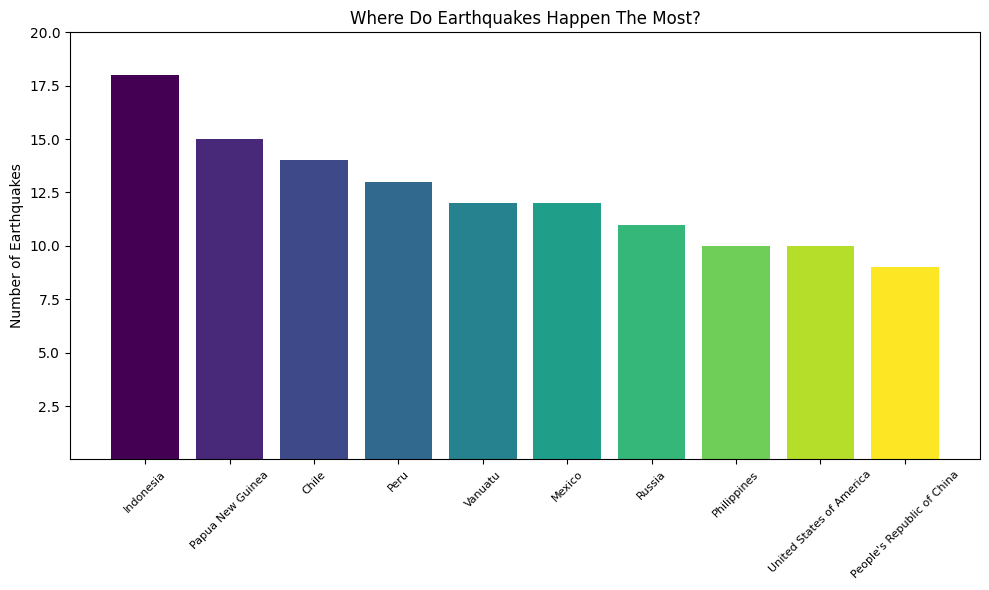

<Figure size 640x480 with 0 Axes>

In [19]:
colors = plt.cm.viridis(np.linspace(0, 1, len(top_10_quakes))) # creating an array of colors for data distinctions

plt.figure(figsize=(10,6))
plt.bar(top_10_quakes.keys(), top_10_quakes.values, color=colors)

plt.title("Where Do Earthquakes Happen The Most?")
plt.xticks(size=8, rotation=45)
plt.ylabel("Number of Earthquakes")
plt.yticks([2.5,5.0,7.5,10.0,12.5,15.0,17.5,20.0])

plt.savefig('most_earthquakes.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()
plt.clf()

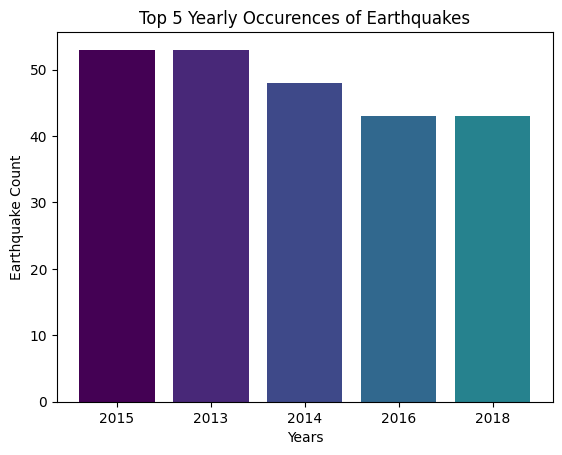

<Figure size 640x480 with 0 Axes>

In [20]:
x_pos = range(len(top_5_quake_years)) # This line has to be here because matplotlib was giving me troubles only refrencing top_5_quake_years.index

plt.figure()
plt.bar(x_pos, top_5_quake_years.values, color=colors)
plt.title("Top 5 Yearly Occurences of Earthquakes")

plt.xticks(x_pos, top_5_quake_years.index)
plt.xlabel("Years")
plt.ylabel("Earthquake Count")

plt.savefig('top5-earthquakes.png', dpi=300, bbox_inches='tight')

plt.show()
plt.clf()

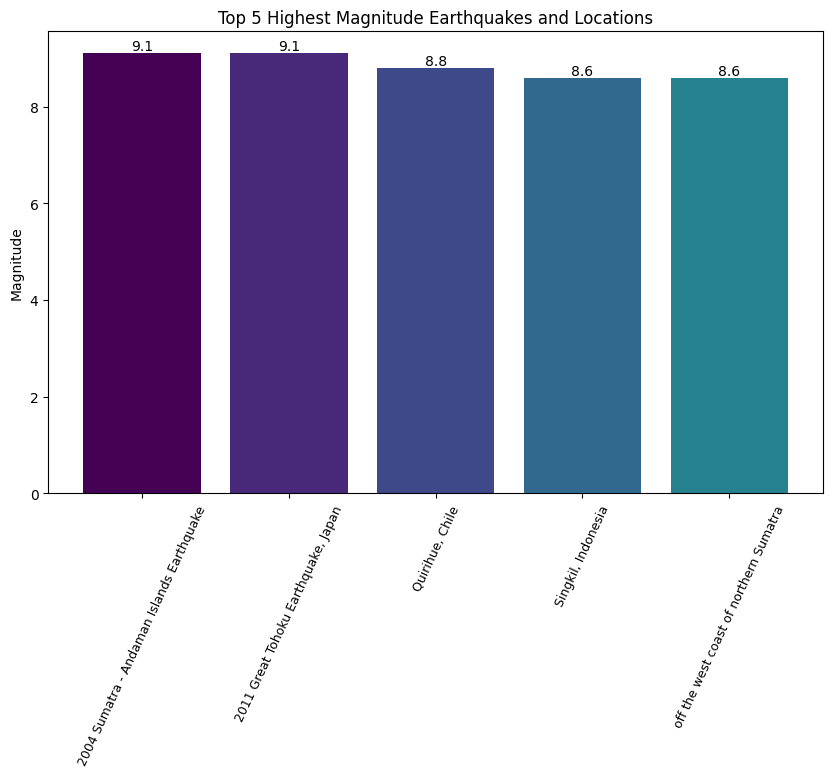

<Figure size 640x480 with 0 Axes>

In [21]:
plt.figure(figsize=(10,6))

bars = plt.bar(top_5_mag_loc['location'],top_5_mag_loc['magnitude'], color=colors)

# The loop below is only for creating numbers ontop of our bars in our barchart
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.1f}',
        ha='center',
        va='bottom'
    )
        

plt.title("Top 5 Highest Magnitude Earthquakes and Locations")
plt.xticks(size=9, rotation=65)
plt.ylabel("Magnitude")

plt.savefig('high-mag-earthquakes.png', dpi=300, bbox_inches='tight')

plt.show()
plt.clf()

In [22]:
# Now for this last graph, Being able to see a plot of countries with the highest average magnitudes (That aren't just one off earthquake occurences) can help us visualize patterns.

                                                    count      mean
country                                                            
Turkiye                                                 3  7.333333
Pakistan                                                5  7.280000
United Kingdom of Great Britain and Northern Ir...      5  7.220000
Peru                                                   26  7.200000
Venezuela                                               2  7.150000
Fiji                                                   10  7.100000
Haiti                                                   2  7.100000
Nepal                                                   4  7.100000
Ecuador                                                10  7.030000
Mexico                                                 31  7.016129


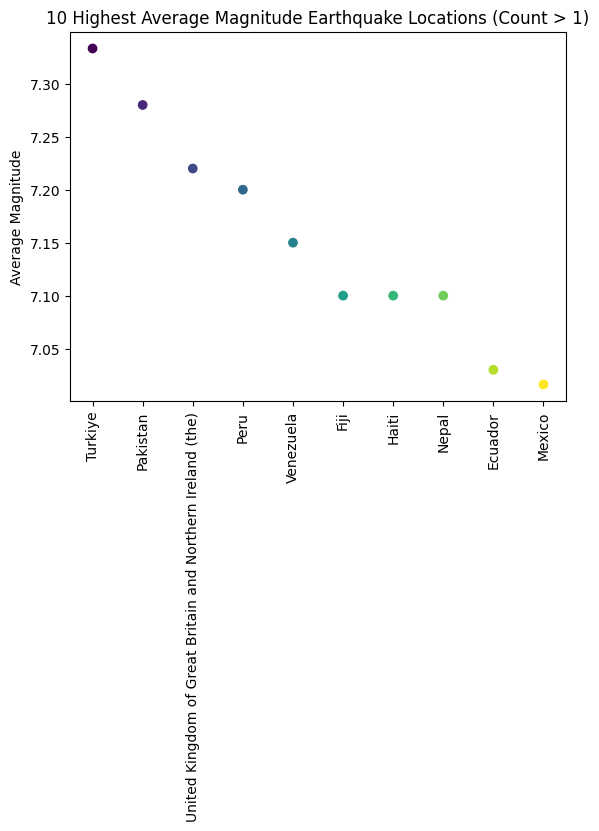

<Figure size 640x480 with 0 Axes>

In [23]:
country_stats = (df.groupby('country')['magnitude'].agg(['count', 'mean']))

filtered_stats = country_stats[country_stats['count'] > 1]

top_10_mean_stats = (filtered_stats.sort_values(by='mean', ascending=False).head(10))
print(top_10_mean_stats)
                                                         
plt.figure()

x_pos = range(len(top_10_mean_stats)) # to make sure the plot accurately appears, added this line precationarily, mentioned the reasons earlier in a comment
colors = plt.cm.viridis(np.linspace(0, 1, len(top_10_mean_stats)))

plt.scatter(x_pos, top_10_mean_stats['mean'], color=colors)

plt.xticks(x_pos, top_10_mean_stats.index, rotation=90)

plt.ylabel('Average Magnitude')
plt.title('10 Highest Average Magnitude Earthquake Locations (Count > 1)') 

plt.savefig('mag-average-earthquakes.png', dpi=300, bbox_inches='tight')

plt.show()
plt.clf()